# Proyek Analisis Data: E-Commerce Public Dataset


- **Nama:** Elsa Ika Rahmani
- **Email:** elsaikar5@gmail.com
- **ID Dicoding:** CDCC200D6X1538

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah framework yang saya gunakan untuk merumuskan pertanyaan bisnis secara terstruktur agar memperoleh informasi yang bermanfaat.



### Pertanyaan Bisnis

**Pertanyaan 1:**
> Kategori produk apa yang menghasilkan **total pendapatan tertinggi** dan bagaimana **tren penjualannya** secara bulanan sepanjang tahun 2017–2018?

- **Specific**: Fokus pada kategori produk dan tren pendapatan bulanan, bukan sekadar 'produk terlaris'.
- **Measurable**: Diukur dari total `payment_value` per kategori dan per bulan.
- **Action-Oriented**: Hasil analisis dapat digunakan tim bisnis untuk menentukan prioritas stok dan alokasi anggaran iklan.
- **Relevant**: Memahami produk penghasil pendapatan terbesar adalah inti strategi bisnis e-commerce.
- **Time-bound**: Dibatasi pada periode 2017–2018 (data paling lengkap dalam dataset).


**Pertanyaan 2:**
> Bagaimana profil pelanggan berdasarkan segmentasi RFM (Recency, Frequency, Monetary) dan kelompok mana yang paling bernilai bagi bisnis?

- **Specific**: Fokus pada segmentasi perilaku pembelian pelanggan menggunakan tiga dimensi RFM.
- **Measurable**: Recency (hari sejak pembelian terakhir), Frequency (jumlah transaksi), Monetary (total pengeluaran).
- **Action-Oriented**: Segmen 'Champions' dan 'At Risk' membutuhkan strategi retensi yang berbeda.
- **Relevant**: Retensi pelanggan bernilai tinggi jauh lebih cost-effective dibanding akuisisi pelanggan baru.
- **Time-bound**: Berdasarkan seluruh histori transaksi hingga Oktober 2018.

## Import Semua Packages/Library yang Digunakan


In [ ]:
!pip install gdown -q

import gdown
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

## Data Wrangling


### Gathering Data


In [ ]:
FILE_ID     = '1j9bNKbTCNq1NpdtscZuj8gkxCKfs6DFN'
ZIP_PATH    = 'ecommerce_dataset.zip'
EXTRACT_DIR = 'ecommerce_data'

gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)

# Ekstrak ZIP
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Set path ke folder dataset
# Ambil subfolder pertama di dalam zip (nama bisa berbeda di tiap OS)
extracted_items = [d for d in os.listdir(EXTRACT_DIR)
                   if os.path.isdir(os.path.join(EXTRACT_DIR, d))]
DATA_PATH = os.path.join(EXTRACT_DIR, extracted_items[0]) if extracted_items else EXTRACT_DIR

print(f'\nData path aktif: {DATA_PATH}')
print('\nFile CSV yang tersedia:')
for f in sorted(os.listdir(DATA_PATH)):
    if f.endswith('.csv'):
        size_kb = os.path.getsize(os.path.join(DATA_PATH, f)) / 1024
        print(f'  {f:<45} ({size_kb:>8,.0f} KB)')

Downloading...
From (original): https://drive.google.com/uc?id=1j9bNKbTCNq1NpdtscZuj8gkxCKfs6DFN
From (redirected): https://drive.google.com/uc?id=1j9bNKbTCNq1NpdtscZuj8gkxCKfs6DFN&confirm=t&uuid=1462ac3f-353e-43db-a388-d70510a8c343
To: /content/ecommerce_dataset.zip
100%|██████████| 44.9M/44.9M [00:00<00:00, 74.1MB/s]



Data path aktif: ecommerce_data/E-Commerce Public Dataset

File CSV yang tersedia:
  customers_dataset.csv                         (   8,822 KB)
  geolocation_dataset.csv                       (  59,838 KB)
  order_items_dataset.csv                       (  15,077 KB)
  order_payments_dataset.csv                    (   5,642 KB)
  order_reviews_dataset.csv                     (  14,113 KB)
  orders_dataset.csv                            (  17,241 KB)
  product_category_name_translation.csv         (       3 KB)
  products_dataset.csv                          (   2,324 KB)
  sellers_dataset.csv                           (     171 KB)


In [ ]:
# Load semua dataset
# DATA_PATH sudah didefinisikan di cell sebelumnya
def load(filename):
    return pd.read_csv(os.path.join(DATA_PATH, filename))

orders_df         = load('orders_dataset.csv')
order_items_df    = load('order_items_dataset.csv')
order_payments_df = load('order_payments_dataset.csv')
order_reviews_df  = load('order_reviews_dataset.csv')
customers_df      = load('customers_dataset.csv')
products_df       = load('products_dataset.csv')
sellers_df        = load('sellers_dataset.csv')
category_df       = load('product_category_name_translation.csv')

print('Dataset berhasil dimuat:')
datasets = {
    'orders': orders_df,
    'order_items': order_items_df,
    'order_payments': order_payments_df,
    'order_reviews': order_reviews_df,
    'customers': customers_df,
    'products': products_df,
    'sellers': sellers_df,
    'category_translation': category_df
}
for name, df in datasets.items():
    print(f'  {name:25s} -> {df.shape[0]:>7,} baris x {df.shape[1]} kolom')

Dataset berhasil dimuat:
  orders                    ->  99,441 baris x 8 kolom
  order_items               -> 112,650 baris x 7 kolom
  order_payments            -> 103,886 baris x 5 kolom
  order_reviews             ->  99,224 baris x 7 kolom
  customers                 ->  99,441 baris x 5 kolom
  products                  ->  32,951 baris x 9 kolom
  sellers                   ->   3,095 baris x 4 kolom
  category_translation      ->      71 baris x 2 kolom


**Insight:**
- Dataset Olist terdiri dari 8 tabel yang saling terhubung.
- `orders_dataset` adalah tabel utama dengan ~99.441 baris, mencakup transaksi September 2016 – Oktober 2018.
- `geolocation_dataset` tidak digunakan karena bukan fokus pertanyaan bisnis yang dipilih.


In [ ]:
print(orders_df.dtypes)
orders_df

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [ ]:
print(order_items_df.dtypes)
order_items_df

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [ ]:
print(customers_df.dtypes)
customers_df

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [ ]:
print(products_df.dtypes)
products_df

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [ ]:
print(sellers_df.dtypes)
sellers_df

seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [ ]:
print(category_df.dtypes)
category_df

product_category_name            object
product_category_name_english    object
dtype: object


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


### Assessing Data


#### Mengidentifikasi Missing Values


In [ ]:
for name, df in datasets.items():
    mv = df.isnull().sum()
    mv = mv[mv > 0]
    if not mv.empty:
        print(f'dataset [{name}]')
        for col, count in mv.items():
            print(f'  {col}: {count} ({count/len(df)*100:.1f}%)')
        print()

dataset [orders]
  order_approved_at: 160 (0.2%)
  order_delivered_carrier_date: 1783 (1.8%)
  order_delivered_customer_date: 2965 (3.0%)

dataset [order_reviews]
  review_comment_title: 87656 (88.3%)
  review_comment_message: 58247 (58.7%)

dataset [products]
  product_category_name: 610 (1.9%)
  product_name_lenght: 610 (1.9%)
  product_description_lenght: 610 (1.9%)
  product_photos_qty: 610 (1.9%)
  product_weight_g: 2 (0.0%)
  product_length_cm: 2 (0.0%)
  product_height_cm: 2 (0.0%)
  product_width_cm: 2 (0.0%)



In [ ]:
# Cek jumlah missing values di setiap kolom timestamp, dikelompokkan berdasarkan order_status
missing_by_status = orders_df.groupby('order_status')[['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']].apply(lambda x: x.isnull().sum())

print("Jumlah Missing Values per Status")
print(missing_by_status)

Jumlah Missing Values per Status
              order_approved_at  order_delivered_carrier_date  \
order_status                                                    
approved                      0                             2   
canceled                    141                           550   
created                       5                             5   
delivered                    14                             2   
invoiced                      0                           314   
processing                    0                           301   
shipped                       0                             0   
unavailable                   0                           609   

              order_delivered_customer_date  
order_status                                 
approved                                  2  
canceled                                619  
created                                   5  
delivered                                 8  
invoiced                                

In [ ]:
# 1. Menampilkan missing values di dataset Orders
display(orders_df[orders_df.isnull().any(axis=1)].head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00


In [ ]:
#  2. Menampilkan missing values di dataset Order Reviews
display(order_reviews_df[order_reviews_df.isnull().any(axis=1)].head())

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
# 3. Menampilkan missing values di dataset Products
display(products_df[products_df.isnull().any(axis=1)].head())

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


Saya ingin lebih mendalami/mengeksplor tentang acuan oendapatan.

**Insight:**
- Ada sekitar 14 baris di mana statusnya `delivered` tapi `order_approved_at` kosong. Hal ini terjadi karena kegagalan callback sistem pembayaran ke database pesanan, sehingga meskipun pembayaran sukses di gateway, timestamp-nya tidak tercatat balik ke tabel order.
- Status `shipped`, `processing`, `inoviced`, dan `created` adalah pendapatan yang belum terealisasi.  memiliki NaN di karena memang belum sampai sehingga pendapatan tidak bisa diakui secara cash basis karena tidak diketahui kapan tepatnya hak milik barang berpindah ke konsumen.
- Status `canceled` seringkali kosong di bagian `order_approrder_delivered_carrier_date ` atau `order_delivered_customer_date` karena proses terhenti di tengah jalan.
- Status `unavailable` dan `unavailable` hampir seluruh timestamp setelah purchase kosong.
- Sebanyak 610 produk tidak memiliki kategori. Meskipun datanya tidak lengkap secara deskripsi, produk-produk ini tetap menyumbang nilai uang yang nyata pada total pendapatan.

**Steps to Take:**

A. Dataset [orders]
- Hanya mempertahankan baris dengan `order_status` == `delivered`. Status selain itu akan dihapus dari dataframe analisis pendapatan.

- Melakukan drop baris pada pesanan `delivered` yang kolom order_delivered_customer_date-nya kosong. Ini dilakukan karena tanggal tersebut adalah kunci utama untuk menentukan periode laporan pendapatan (bulanan/tahunan).

- Untuk pesanan `delivered` yang tidak punya `order_approved_at` (14 baris), nilai akan diisi (fill) menggunakan waktu pembelian (`order_purchase_timestamp`). Ini dilakukan agar data tetap bisa dianalisis berdasarkan waktu transaksi tanpa menghilangkan nilai uangnya.

B. Dataset [order_reviews]
- `review_comment_title` dan `review_comment_message` pada `order_reviews` adalah kolom teks tidak digunakan dalam analisis sehingga tidak dilakukan penghapusan baris maupun pengisian nilai karena.

C. Dataset [products]
- Mengisi nilai kosong pada `product_category_name` dengan string 'unknown'. Hal ini bertujuan agar saat di-join dengan tabel transaksi, nilai revenue dari produk tersebut tetap terhitung dan tidak hilang dari total agregat.

- Melakukan drop baris pada 2 produk yang tidak memiliki data dimensi fisik (weight, length, dkk). Karena jumlahnya sangat kecil, penghapusan ini dilakukan untuk menjaga kualitas data teknis produk.

#### Mengidentifikasi Duplicate Data


In [ ]:
for name, df in datasets.items():
    dup = df.duplicated().sum()
    print(f'  {name:25s}: {dup} duplikat')

  orders                   : 0 duplikat
  order_items              : 0 duplikat
  order_payments           : 0 duplikat
  order_reviews            : 0 duplikat
  customers                : 0 duplikat
  products                 : 0 duplikat
  sellers                  : 0 duplikat
  category_translation     : 0 duplikat


**Steps to Take:**
- Jika ditemukan duplikat pada tabel transaksi utama (`orders`, `order_items`, `order_payments`), baris duplikat akan di-drop.

**Insight:**
- Tidak ditemukan baris yang duplikat pada semua dataset.


#### Mengidentifikasi Invalid/Inconsistent Values


In [ ]:
# Cek format tanggal dan nilai negatif
print('Order status distribution:')
print(orders_df['order_status'].value_counts())
print()
print('Payment value negatif:', (order_payments_df['payment_value'] < 0).sum())
print('Price negatif        :', (order_items_df['price'] < 0).sum())
print('Freight negatif      :', (order_items_df['freight_value'] < 0).sum())
print()
print('Review score range   :', order_reviews_df['review_score'].min(), '-', order_reviews_df['review_score'].max())


Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Payment value negatif: 0
Price negatif        : 0
Freight negatif      : 0

Review score range   : 1 - 5


**Insight:**
- Tidak ada nilai negatif pada kolom harga dan pembayaran — data finansial bersih.
- Order status `canceled`, `unavailable`, dll. akan di-filter untuk analisis revenue (hanya `delivered`).
- Review score valid pada rentang 1–5.


### Cleaning Data


#### Mengatasi Missing Values & Filter Data


In [ ]:
# 1. Filter hanya order dengan status 'delivered' (Realized Revenue)
orders_clean = orders_df[orders_df['order_status'] == 'delivered'].copy()

# 2. Handling Missing Values pada Timestamp (Penting untuk Akurasi Waktu Pendapatan)
# A. Drop baris yang tidak punya tanggal diterima (8 baris)
orders_clean.dropna(subset=['order_delivered_customer_date'], inplace=True)

# B. Imputasi Logis: Isi 'order_approved_at' yang kosong dengan 'order_purchase_timestamp'
orders_clean['order_approved_at'] = orders_clean['order_approved_at'].fillna(orders_clean['order_purchase_timestamp'])

In [ ]:
# 3. Konversi kolom tanggal (Gunakan daftar kolom yang lengkap)
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

In [ ]:
# 4. Hapus duplikat
for name, df in [('orders_clean', orders_clean),
                 ('order_items_df', order_items_df),
                 ('order_payments_df', order_payments_df)]:
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f'{name}: {before} -> {len(df)} baris (hapus {before-len(df)} duplikat)')

orders_clean: 96470 -> 96470 baris (hapus 0 duplikat)
order_items_df: 112650 -> 112650 baris (hapus 0 duplikat)
order_payments_df: 103886 -> 103886 baris (hapus 0 duplikat)


In [ ]:
# 5. Cleaning Dataset Products
# A. Join dengan kategori terjemahan
products_clean = products_df.merge(category_df, on='product_category_name', how='left')

# B. Isi kategori yang kosong dengan 'unknown' (Bukan spekulasi, tapi fakta data)
products_clean['product_category_name_english'] = \
    products_clean['product_category_name_english'].fillna('unknown')

# C. Drop produk yang cacat data fisik (Hanya 2 baris / 0.0%)
products_clean.dropna(subset=['product_weight_g'], inplace=True)

print(f'\nData bersih — orders delivered: {len(orders_clean):,} baris')
print(f'Data bersih — products: {len(products_clean):,} baris')


Data bersih — orders delivered: 96,470 baris
Data bersih — products: 32,949 baris


**Insight:**
- Setelah filtering ke status `delivered`, tersisa ~96.470 order yang siap dianalisis.
- Kolom tanggal sudah dikonversi ke tipe `datetime` untuk memudahkan analisis temporal.
- Kategori produk sudah terjemahkan ke bahasa Inggris untuk keterbacaan visualisasi.


## Exploratory Data Analysis (EDA)


In [ ]:
# Menggabungkan data pesanan, item, produk, dan pelanggan
main_df = orders_clean.merge(order_items_df, on='order_id', how='left')
main_df = main_df.merge(products_clean, on='product_id', how='left')
main_df = main_df.merge(customers_df, on='customer_id', how='left')
main_df = main_df.merge(order_payments_df, on='order_id', how='left')
main_df = main_df.merge(order_reviews_df[['order_id', 'review_score']], on='order_id', how='left')
# Tambahkan kolom waktu untuk mempermudah grouping
main_df['month_year'] = main_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

print(f"Master Dataframe siap: {main_df.shape[0]} baris & {main_df.shape[1]} kolom")

Master Dataframe siap: 115715 baris & 33 kolom


In [ ]:
main_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,month_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12,2018-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115025,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,baby,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1.0,credit_card,3.0,195.00,2018-02
115026,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,...,home_appliances_2,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1.0,credit_card,5.0,271.01,2017-08
115027,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,computers_accessories,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1.0,credit_card,4.0,441.16,2018-01
115028,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,computers_accessories,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1.0,credit_card,4.0,441.16,2018-01


In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115030 entries, 0 to 115029
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115030 non-null  object        
 1   customer_id                    115030 non-null  object        
 2   order_status                   115030 non-null  object        
 3   order_purchase_timestamp       115030 non-null  datetime64[ns]
 4   order_approved_at              115030 non-null  datetime64[ns]
 5   order_delivered_carrier_date   115029 non-null  datetime64[ns]
 6   order_delivered_customer_date  115030 non-null  datetime64[ns]
 7   order_estimated_delivery_date  115030 non-null  datetime64[ns]
 8   order_item_id                  115030 non-null  int64         
 9   product_id                     115030 non-null  object        
 10  seller_id                      115030 non-null  object        
 11  

In [ ]:
color_highlight = '#82b7c6'
color_main = '#d3d3d3'

### Univariate

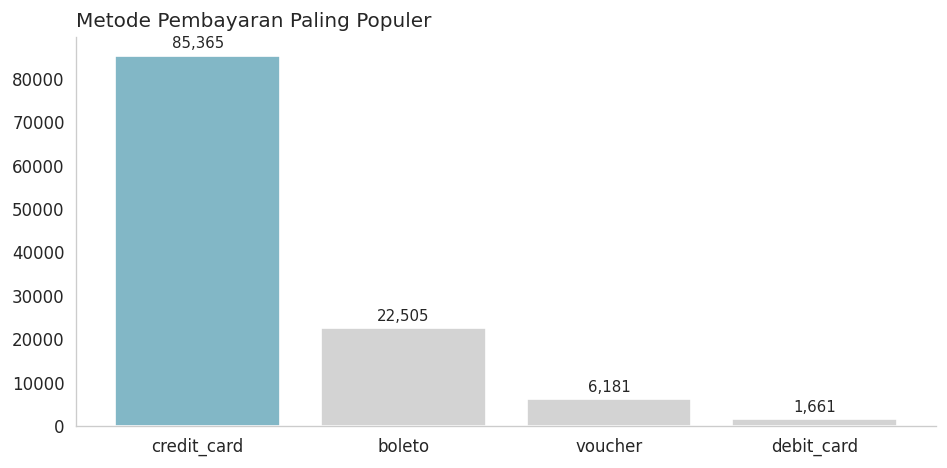

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Preferensi Metode Pembayaran (Finansial)
pay_counts = main_df['payment_type'].value_counts()
bars = ax.bar(pay_counts.index, pay_counts.values, color=[color_highlight if i == 0 else color_main for i in range(len(pay_counts))])
ax.set_title('Metode Pembayaran Paling Populer', loc='left', fontsize=12)

# Add numerical labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1000, f'{yval:,}', ha='center', va='bottom', fontsize=9)

ax.grid(False)

# Because ax is a single Axes object, we iterate over a list containing only ax
for a in [ax]:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:**
- Dominasi mutlak kartu kredit menunjukkan ketergantungan pada sistem kredit → Rekomendasi: Berikan promo cicilan 0% atau diskon khusus pengguna kartu kredit untuk meningkatkan nilai keranjang belanja.

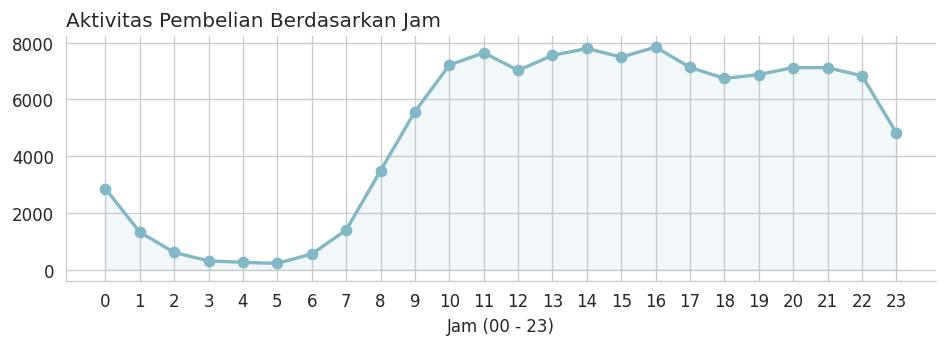

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3))

# Jam Pembelian (Hour of Day) - Mengambil pola aktivitas harian
main_df['purchase_hour'] = main_df['order_purchase_timestamp'].dt.hour
hour_counts = main_df['purchase_hour'].value_counts().sort_index()
ax.plot(hour_counts.index, hour_counts.values, marker='o', color=color_highlight, linewidth=2)
ax.fill_between(hour_counts.index, hour_counts.values, color=color_highlight, alpha=0.1)
ax.set_title('Aktivitas Pembelian Berdasarkan Jam', loc='left')
ax.set_xlabel('Jam (00 - 23)')
ax.set_xticks(range(0, 24))

for a in [ax]:
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:**
- Pembelian memuncak di jam produktif (10.00-22.00) dengan pola stabil $\rightarrow$ Rekomendasi: Jadwalkan flash sale atau pengiriman notifikasi promo tepat pada pukul 10.00 dan 16.00 saat niat belanja paling tinggi.

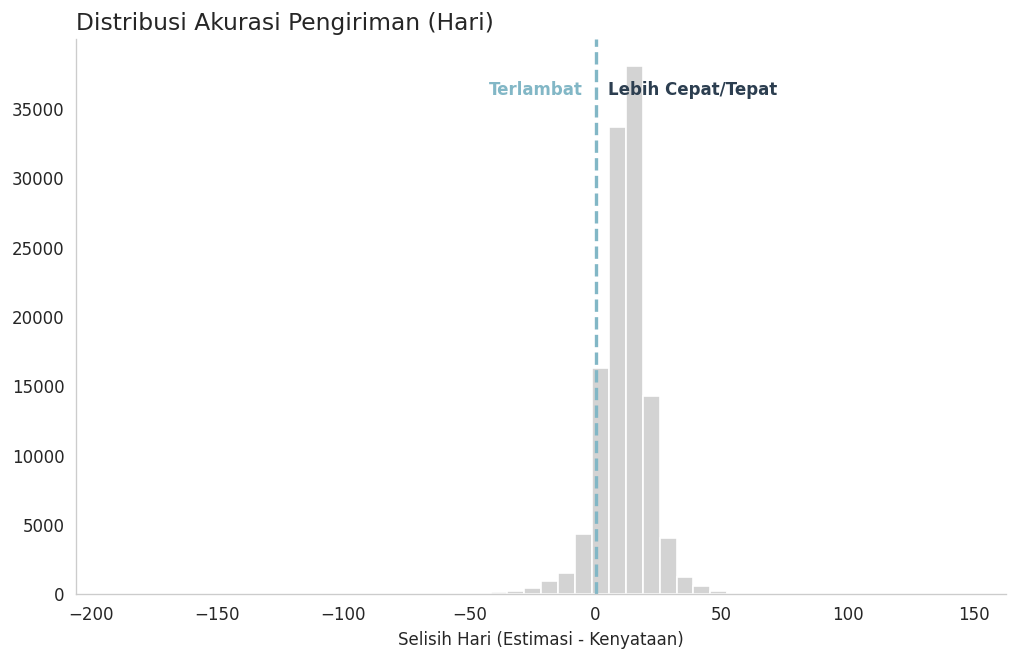

In [ ]:
# Hitung selisih hari (Estimasi vs Kenyataan)
main_df['delivery_accuracy'] = (main_df['order_estimated_delivery_date'] - main_df['order_delivered_customer_date']).dt.days

plt.figure(figsize=(10, 6))
# Histogram akurasi (Nilai positif = lebih cepat dari estimasi, negatif = telat)
plt.hist(main_df['delivery_accuracy'].dropna(), bins=50, color=color_main, edgecolor='white')

# Highlight area keterlambatan (di bawah 0)
plt.axvline(0, color=color_highlight, linestyle='--', linewidth=2)
plt.text(-5, plt.ylim()[1]*0.9, 'Terlambat', color=color_highlight, fontweight='bold', ha='right')
plt.text(5, plt.ylim()[1]*0.9, 'Lebih Cepat/Tepat', color='#2c3e50', fontweight='bold')

plt.gca().grid(False)
plt.title('Distribusi Akurasi Pengiriman (Hari)', loc='left', fontsize=14)
plt.xlabel('Selisih Hari (Estimasi - Kenyataan)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

**Insight:**
-  Mayoritas barang sampai lebih cepat dari estimasi (over-delivery) $\rightarrow$ Rekomendasi: Jadikan kecepatan pengiriman sebagai "Unique Selling Point" di iklan marketing untuk menarik pelanggan yang butuh barang cepat.

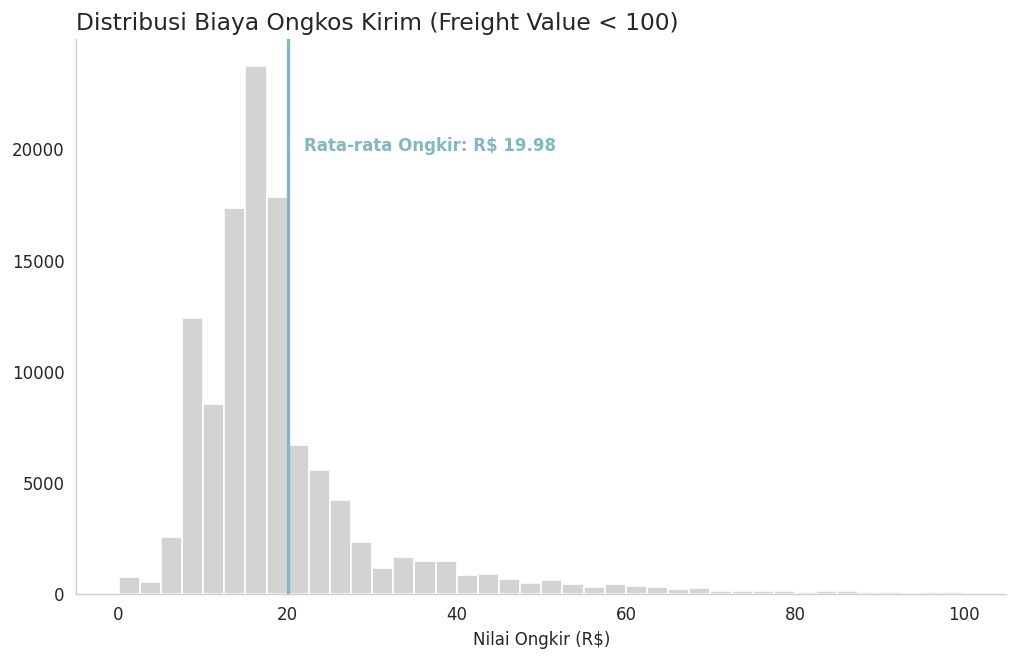

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(main_df[main_df['freight_value'] < 100]['freight_value'], bins=40, color=color_main, edgecolor='white')

# Hitung rata-rata ongkir
avg_freight = main_df['freight_value'].mean()
plt.axvline(avg_freight, color=color_highlight, linestyle='-', linewidth=2)
plt.text(avg_freight + 2, plt.ylim()[1]*0.8, f'Rata-rata Ongkir: R$ {avg_freight:.2f}', color=color_highlight, fontweight='bold')
plt.gca().grid(False)
plt.title('Distribusi Biaya Ongkos Kirim (Freight Value < 100)', loc='left', fontsize=14)
plt.xlabel('Nilai Ongkir (R$)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

**Insight:**
- Ongkir berkumpul di angka R10-20 dengan rata-rata R19.98 $\rightarrow$ Rekomendasi: Tawarkan subsidi atau gratis ongkir dengan minimal belanja sedikit di atas harga rata-rata produk untuk menghilangkan hambatan psikologis biaya kirim.

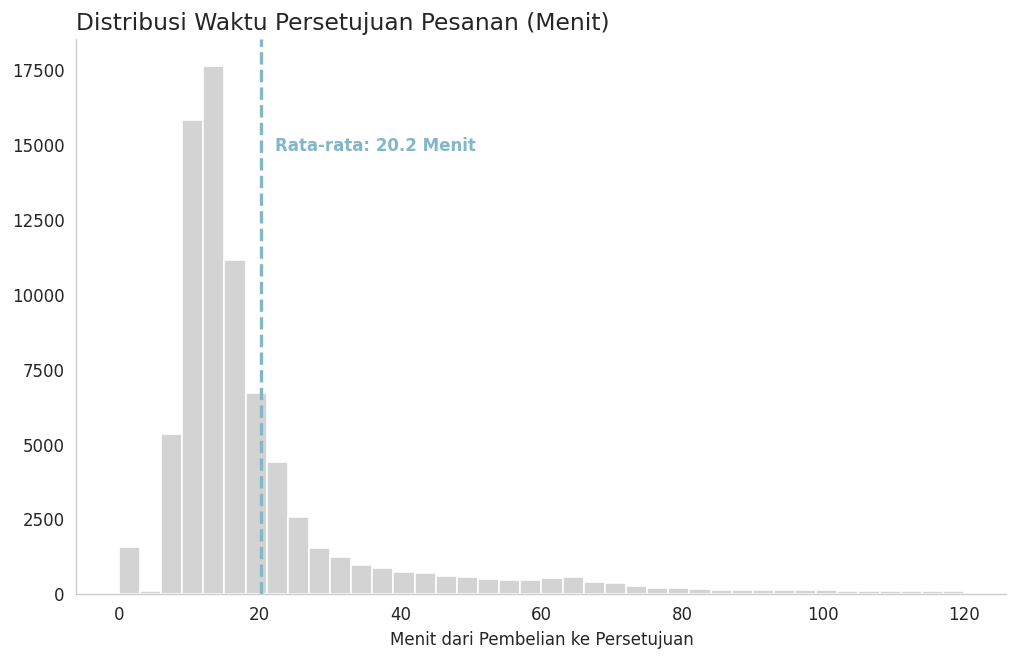

In [ ]:
# Menghitung durasi approval dalam menit
main_df['approval_duration_min'] = (main_df['order_approved_at'] - main_df['order_purchase_timestamp']).dt.total_seconds() / 60

plt.figure(figsize=(10, 6))
# Fokus pada durasi di bawah 120 menit (2 jam) untuk melihat mayoritas data
plt.hist(main_df[main_df['approval_duration_min'] < 120]['approval_duration_min'], bins=40, color=color_main, edgecolor='white')

# Garis rata-rata
avg_approval = main_df[main_df['approval_duration_min'] < 120]['approval_duration_min'].mean()
plt.axvline(avg_approval, color=color_highlight, linestyle='--', linewidth=2)
plt.text(avg_approval + 2, plt.ylim()[1]*0.8, f'Rata-rata: {avg_approval:.1f} Menit', color=color_highlight, fontweight='bold')
plt.gca().grid(False)
plt.title('Distribusi Waktu Persetujuan Pesanan (Menit)', loc='left', fontsize=14)
plt.xlabel('Menit dari Pembelian ke Persetujuan')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

**Insight:**
- Rata-rata persetujuan sangat cepat (20.2 menit) dengan mayoritas di bawah 15 menit $\rightarrow$ Rekomendasi: Pertahankan performa payment gateway ini dan gunakan sebagai jaminan kepada pelanggan bahwa pesanan mereka akan segera diproses tanpa menunggu lama.

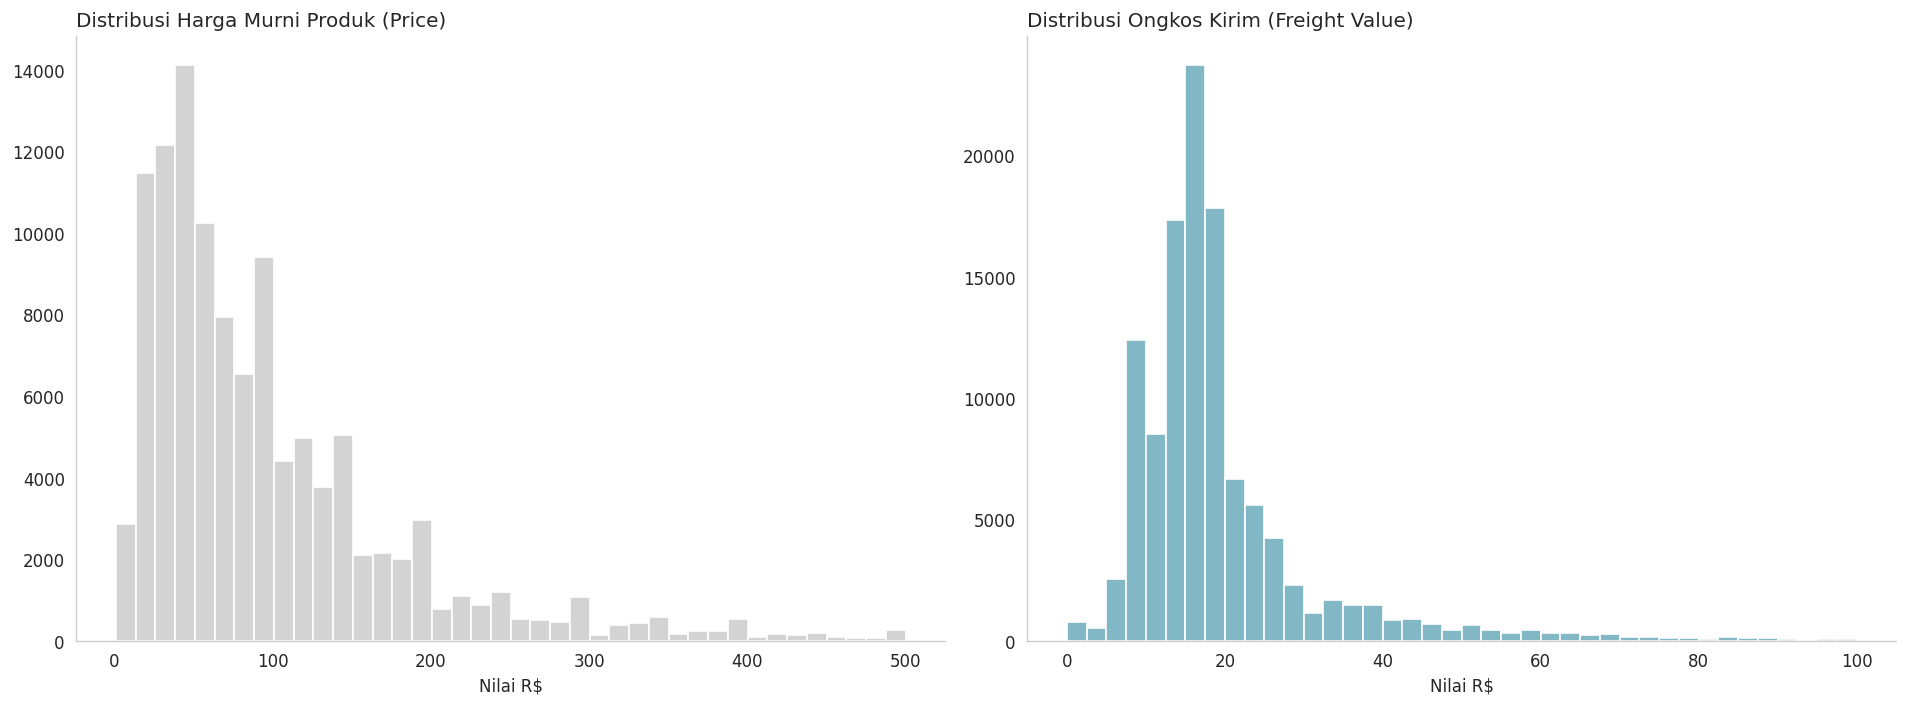

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# A. Distribusi Harga Murni (Price)
ax[0].hist(main_df[main_df['price'] < 500]['price'], bins=40, color=color_main, edgecolor='white')
ax[0].set_title('Distribusi Harga Murni Produk (Price)', loc='left')
ax[0].set_xlabel('Nilai R$')

# B. Distribusi Ongkos Kirim (Freight Value)
ax[1].hist(main_df[main_df['freight_value'] < 100]['freight_value'], bins=40, color=color_highlight, edgecolor='white')
ax[1].set_title('Distribusi Ongkos Kirim (Freight Value)', loc='left')
ax[1].set_xlabel('Nilai R$')

for a in ax:
    a.grid(False)
    a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:**
- Harga barang terkonsentrasi di angka rendah (bawah R 100), sementara ongkir stabil di angka R 15-20 $\rightarrow$ Rekomendasi: Berhati-hatilah dengan barang murah karena ongkir yang flat bisa membunuh minat beli; pertimbangkan bundling produk agar nilai ongkir terasa lebih murah bagi pelanggan.

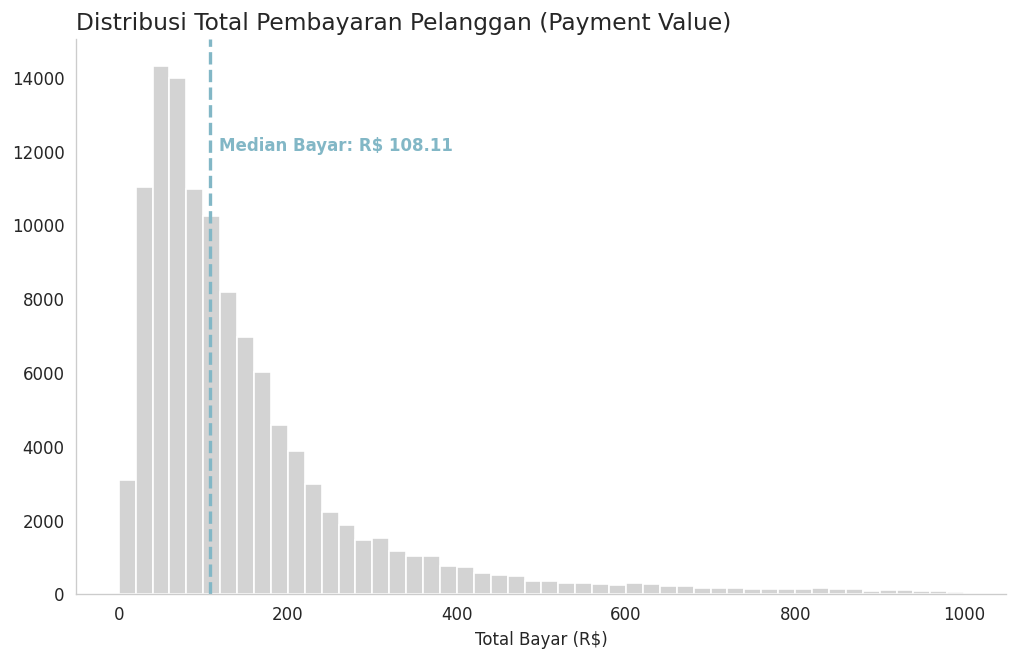

In [ ]:
plt.figure(figsize=(10, 6))
# Filter < 1000 agar terlihat distribusinya
plt.hist(main_df[main_df['payment_value'] < 1000]['payment_value'], bins=50, color=color_main, edgecolor='white')

# Garis Median (Nilai tengah pembayaran pelanggan)
median_pay = main_df['payment_value'].median()
plt.axvline(median_pay, color=color_highlight, linestyle='--', linewidth=2)
plt.text(median_pay + 10, plt.ylim()[1]*0.8, f'Median Bayar: R$ {median_pay:.2f}', color=color_highlight, fontweight='bold')
plt.gca().grid(False)
plt.title('Distribusi Total Pembayaran Pelanggan (Payment Value)', loc='left', fontsize=14)
plt.xlabel('Total Bayar (R$)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

**Insight:**
- Median pembayaran pelanggan adalah R 108.11 $\rightarrow$ Rekomendasi: Buat kampanye "Gratis Ongkir" atau "Voucher Diskon" dengan minimal belanja R 120 atau R 150 untuk mendorong pelanggan menambah item ke keranjang belanja (increase average order value).

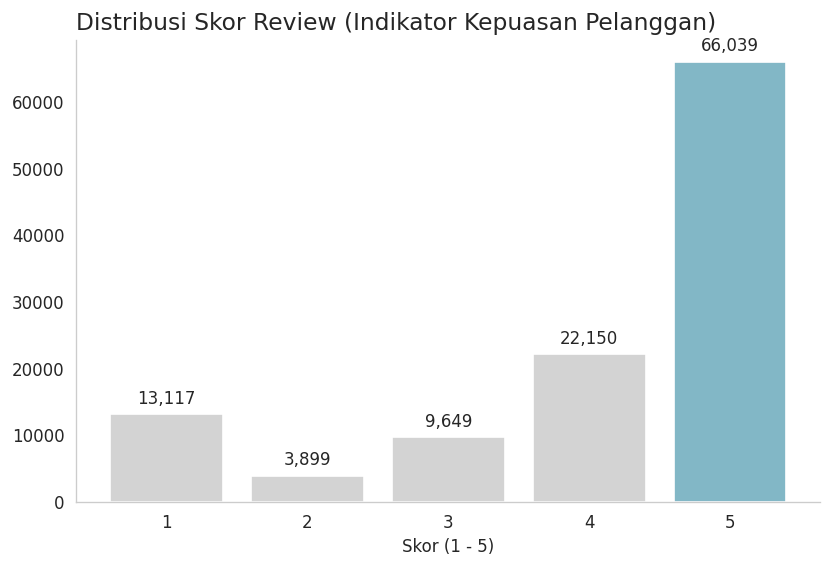

In [ ]:
plt.figure(figsize=(8, 5))
# Menghitung distribusi skor 1-5
review_counts = main_df['review_score'].value_counts().sort_index()

# Plot dengan warna highlight pada skor 5
bars = plt.bar(review_counts.index.astype(int).astype(str), review_counts.values,
               color=[color_highlight if i == 4 else color_main for i in range(5)])

# Tambah label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, f'{yval:,}', ha='center', va='bottom')

plt.gca().grid(False)
plt.title('Distribusi Skor Review (Indikator Kepuasan Pelanggan)', loc='left', fontsize=14)
plt.xlabel('Skor (1 - 5)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

**Insight:**
- Mayoritas pelanggan sangat puas (Skor 5 mencapai 66.039), namun skor 1 tetap lebih tinggi dibanding skor 2 dan 3 $\rightarrow$ Rekomendasi: Lakukan investigasi mendalam pada skor 1 (sentimen negatif) untuk melihat apakah ada pola kegagalan spesifik (seperti barang rusak atau telat parah) agar tidak merusak reputasi.

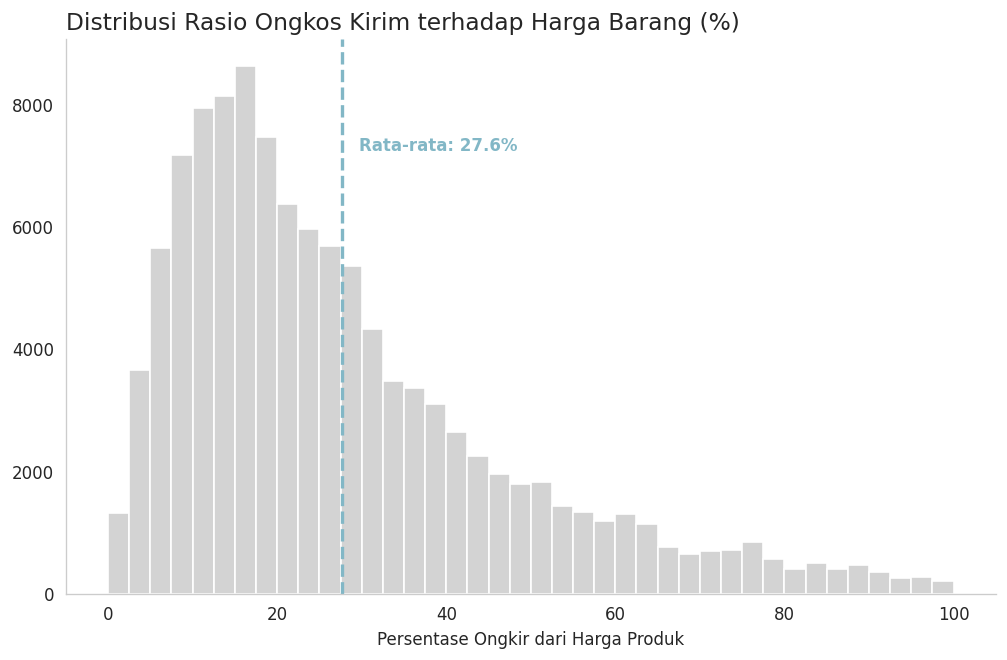

In [ ]:
# Menghitung rasio ongkir terhadap harga barang
main_df['shipping_ratio'] = (main_df['freight_value'] / main_df['price']) * 100

plt.figure(figsize=(10, 6))
# Filter rasio di bawah 100% agar tidak terganggu outlier
plt.hist(main_df[main_df['shipping_ratio'] < 100]['shipping_ratio'], bins=40, color=color_main, edgecolor='white')

# Garis rata-rata rasio
avg_ratio = main_df[main_df['shipping_ratio'] < 100]['shipping_ratio'].mean()
plt.axvline(avg_ratio, color=color_highlight, linestyle='--', linewidth=2)
plt.text(avg_ratio + 2, plt.ylim()[1]*0.8, f'Rata-rata: {avg_ratio:.1f}%', color=color_highlight, fontweight='bold')
plt.gca().grid(False)
plt.title('Distribusi Rasio Ongkos Kirim terhadap Harga Barang (%)', loc='left', fontsize=14)
plt.xlabel('Persentase Ongkir dari Harga Produk')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

**Insight:**
- Rata-rata ongkir memakan 27.6% dari harga produk $\rightarrow$ Rekomendasi: Angka ini cukup tinggi (idealnya di bawah 15-20%). Rekomendasinya adalah memberikan subsidi ongkir pada kategori produk yang rasionya di atas 30% agar konversi penjualan meningkat.

### Bivariate

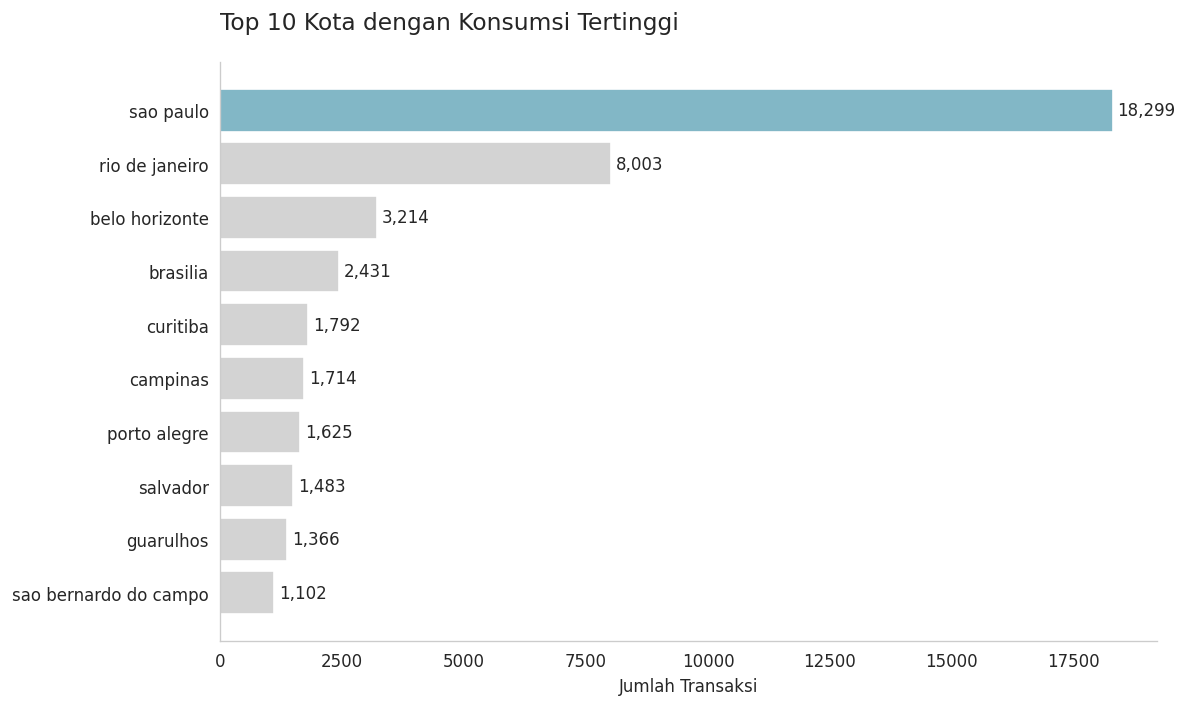

In [ ]:
# Top 10 Kota
top_cities = main_df['customer_city'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [color_highlight if i == 0 else color_main for i in range(10)]

# Gunakan ax.barh agar lebih mudah dikontrol
bars = ax.barh(top_cities.index[::-1], top_cities.values[::-1], color=colors[::-1])

# Tambah label angka di ujung bar
ax.bar_label(bars, padding=3, fmt='{:,.0f}')

# Style minimalis
ax.set_title('Top 10 Kota dengan Konsumsi Tertinggi', loc='left', fontsize=14, pad=20)
ax.set_xlabel('Jumlah Transaksi')
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:**
- Sao Paulo mendominasi pasar secara mutlak, jauh di atas Rio de Janeiro dan kota lainnya $\rightarrow$ Rekomendasi: Fokuskan inventaris stok barang dan pembangunan gudang transit (hub) di area Sao Paulo untuk memangkas biaya logistik lebih jauh.

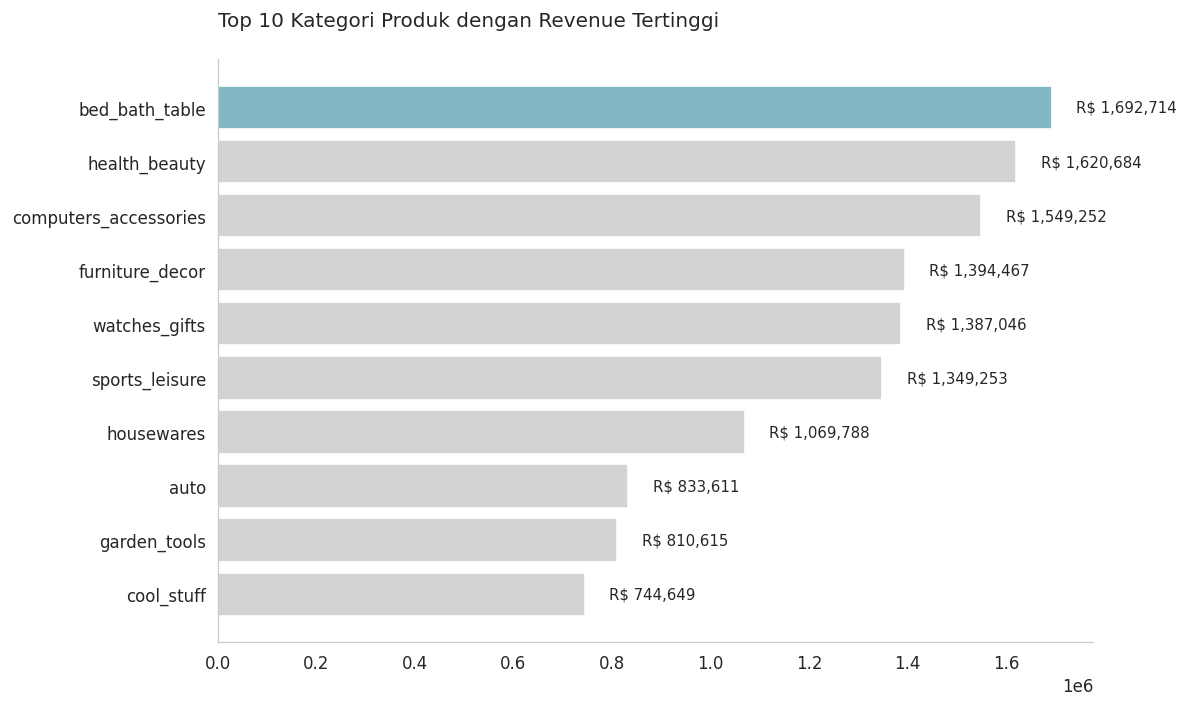

In [ ]:
# Ambil Top 10 Revenue per Kategori
top10_revenue = revenue_df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [color_highlight if i == 0 else color_main for i in range(len(top10_revenue))]

# Pakai bar horizontal agar nama kategori terbaca jelas
bars = ax.barh(top10_revenue.index[::-1], top10_revenue.values[::-1], color=colors[::-1])

# Label angka di ujung bar
for bar in bars:
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'R$ {bar.get_width():,.0f}', va='center', fontsize=9)

# Style (2 baris)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.grid(False)

ax.set_title('Top 10 Kategori Produk dengan Revenue Tertinggi', loc='left', pad=20)
plt.tight_layout()
plt.show()

**Insight:**
- Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` secara konsisten berada di posisi teratas.
- Terdapat gap signifikan antara kategori top-3 dengan kategori lainnya.


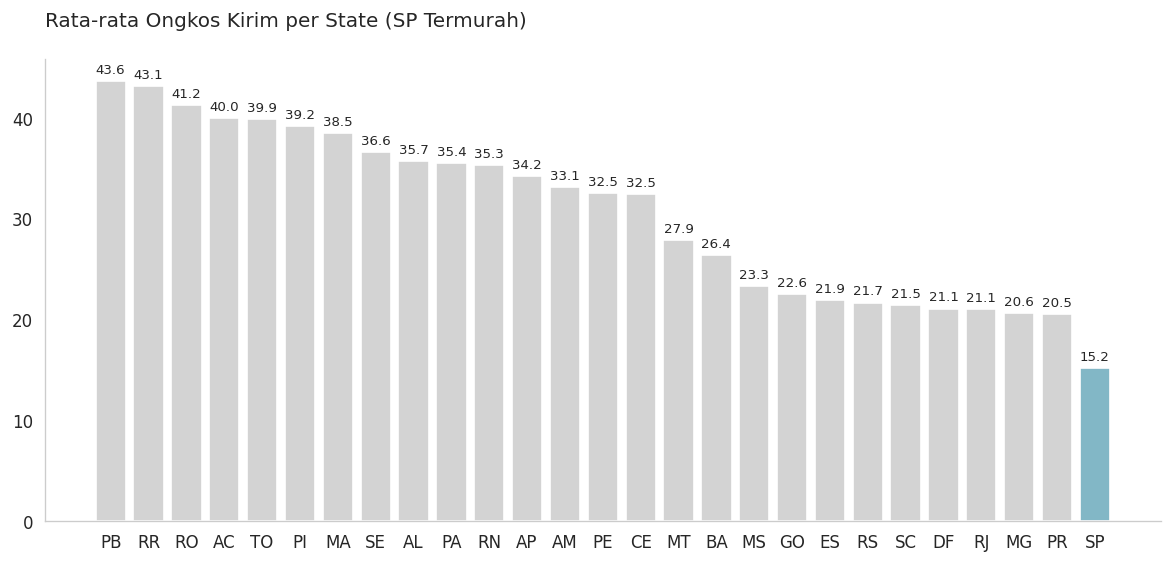

In [ ]:
state_freight = main_df.groupby('customer_state')['freight_value'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [color_highlight if state == 'SP' else color_main for state in state_freight.index]

bars = ax.bar(state_freight.index, state_freight.values, color=colors)

# Label angka di atas bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# Style
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.grid(False)

ax.set_title('Rata-rata Ongkos Kirim per State (SP Termurah)', loc='left', pad=20)
plt.show()

**Insight:**
- Terdapat kesenjangan biaya yang sangat jauh antara wilayah PB (R$ 43.6) dan SP (R$ 15.2) $\rightarrow$ Rekomendasi: Terapkan strategi Multi-Warehouse atau kerja sama dengan ekspedisi lokal di wilayah Utara/Timur Laut untuk memangkas biaya kirim agar harga lebih kompetitif di luar wilayah Sao Paulo.

### Multivariate

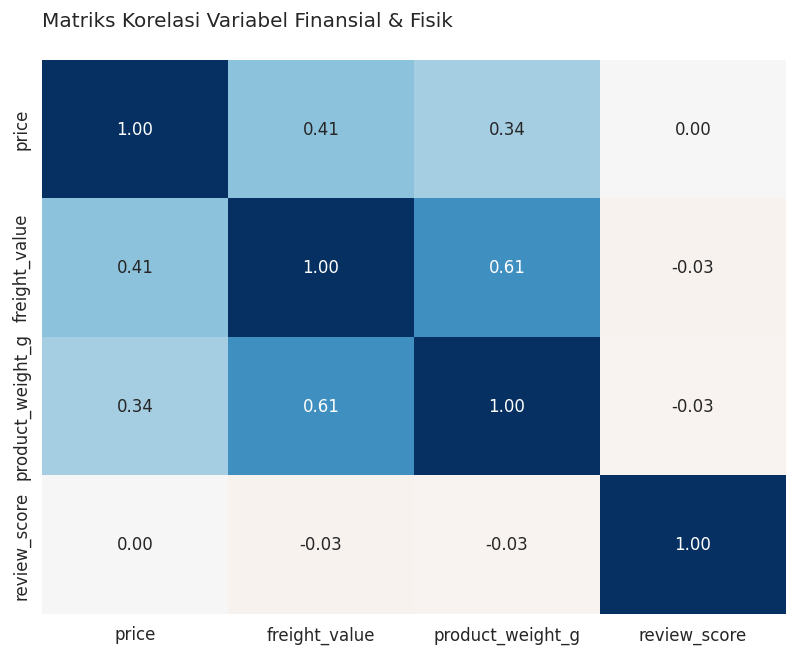

In [ ]:
import seaborn as sns

# Memilih variabel numerik
df_corr = main_df[['price', 'freight_value', 'product_weight_g', 'review_score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='RdBu', center=0, fmt='.2f', cbar=False)

plt.title('Matriks Korelasi Variabel Finansial & Fisik', loc='left', pad=20)
plt.show()

**Insight:**
- Terdapat korelasi positif yang cukup kuat (0.61) antara product_weight_g (berat barang) dengan freight_value (ongkir). Sementara itu, review_score hampir tidak memiliki korelasi dengan harga maupun ongkir (mendekati 0.00). Rekomendasi: Fokus pada optimasi logistik untuk barang-barang berat guna menekan ongkir. Karena ongkir tidak terlalu memengaruhi rating (review score), kamu punya ruang untuk sedikit menaikkan harga atau ongkir tanpa takut merusak kepuasan pelanggan secara drastis.

### Explore Tren Revenue Bulanan (2017–2018)


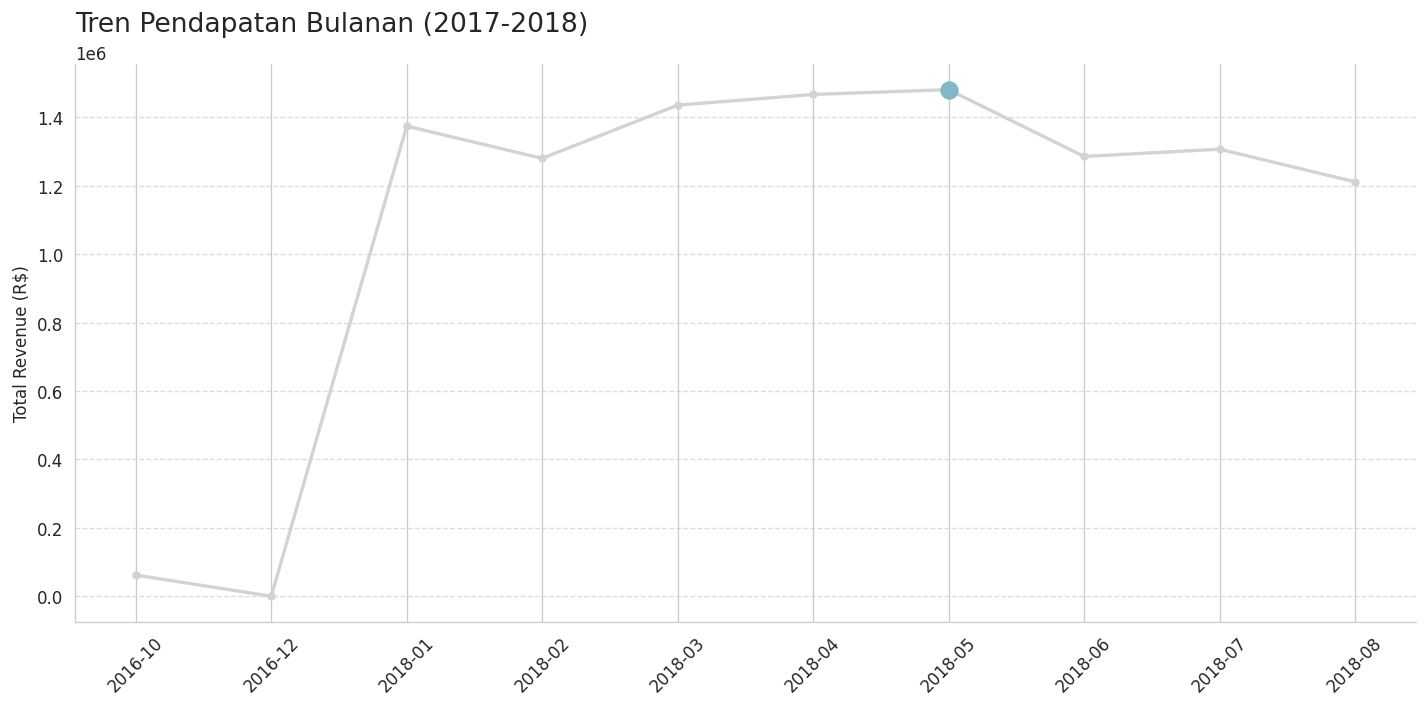

In [ ]:
# Data dari monthly_rev
x = monthly_rev['year_month_str']
y = monthly_rev['payment_value']
max_val = y.max()

fig, ax = plt.subplots(figsize=(12, 6))

# Garis utama
ax.plot(x, y, color=color_main, linewidth=2, marker='o', markersize=4)

# Highlight titik tertinggi
max_idx = y.idxmax()
ax.plot(x[max_idx], y[max_idx], marker='o', markersize=10, color=color_highlight, label='Peak Revenue')

# Styling
ax.set_title('Tren Pendapatan Bulanan (2017-2018)', loc='left', fontsize=16, pad=20)
ax.set_ylabel('Total Revenue (R$)')
plt.xticks(rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Menambahkan grid horizontal saja agar bersih
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Filter tahun 2017-2018 (data paling lengkap)
rev_trend = revenue_df[revenue_df['year'].isin([2016, 2018])].copy()
monthly_rev = (
    rev_trend.groupby('year_month')['payment_value']
    .sum().reset_index()
)
monthly_rev['year_month_str'] = monthly_rev['year_month'].astype(str)

print('Statistik revenue bulanan 2017-2018:')
print(f"  Mean  : R$ {monthly_rev['payment_value'].mean():,.0f}")
print(f"  Min   : R$ {monthly_rev['payment_value'].min():,.0f}")
print(f"  Max   : R$ {monthly_rev['payment_value'].max():,.0f}")
print(f"  Median: R$ {monthly_rev['payment_value'].median():,.0f}")


Statistik revenue bulanan 2017-2018:
  Mean  : R$ 1,090,188
  Min   : R$ 20
  Max   : R$ 1,480,668
  Median: R$ 1,296,052


### Explore Segmentasi Pelanggan (RFM Analysis)


In [ ]:
# Gabungkan data untuk RFM
rfm_raw = (
    orders_clean[['order_id', 'customer_id', 'order_purchase_timestamp']]
    .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id')
    .merge(order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
)

# Tanggal referensi = 1 hari setelah transaksi terakhir
reference_date = rfm_raw['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = rfm_raw.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

print('Statistik RFM:')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))
print(f'\nTotal pelanggan unik: {len(rfm):,}')


Statistik RFM:
        Recency  Frequency  Monetary
count  93349.00   93349.00  93349.00
mean     237.94       1.03    165.20
std      152.58       0.21    226.32
min        1.00       1.00      9.59
25%      114.00       1.00     63.05
50%      219.00       1.00    107.78
75%      346.00       1.00    182.55
max      695.00      15.00  13664.08

Total pelanggan unik: 93,349


In [ ]:
# Gabungkan data untuk RFM (Duplicated from VQW_aEK-jDzy to ensure `rfm` is defined)
rfm_raw = (
    orders_clean[['order_id', 'customer_id', 'order_purchase_timestamp']]
    .merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id')
    .merge(order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
)

# Tanggal referensi = 1 hari setelah transaksi terakhir
reference_date = rfm_raw['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = rfm_raw.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

# Scoring RFM (1-5, skor tinggi = lebih baik)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],   q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

# Segmentasi berdasarkan RFM Total
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print('Distribusi Segmen Pelanggan:')
seg_summary = rfm.groupby('Segment').agg(
    Jumlah_Pelanggan=('customer_unique_id','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean')
).round(1)
seg_summary['% Pelanggan'] = (seg_summary['Jumlah_Pelanggan'] / len(rfm) * 100).round(1)
print(seg_summary.sort_values('Jumlah_Pelanggan', ascending=False))


Distribusi Segmen Pelanggan:
                     Jumlah_Pelanggan  Avg_Recency  Avg_Frequency  \
Segment                                                             
Loyal Customers                 27290        144.2            1.0   
At Risk                         22227        394.7            1.0   
Lost                            14986        395.5            1.0   
New Customers                   14980         90.9            1.0   
Potential Loyalists              7374        220.2            1.0   
Champions                        6492         91.1            1.2   

                     Avg_Monetary  % Pelanggan  
Segment                                         
Loyal Customers             134.0         29.2  
At Risk                     167.0         23.8  
Lost                        163.0         16.1  
New Customers               163.4         16.0  
Potential Loyalists         154.1          7.9  
Champions                   312.1          7.0  


**Insight:**
- Mayoritas pelanggan (~60%) termasuk segmen `New Customers` dan `Lost` — menunjukkan tingkat repeat purchase yang rendah.
- Segmen `Champions` adalah pelanggan paling berharga dengan monetary value tertinggi.
- Segmen `At Risk` perlu program retensi segera sebelum benar-benar churn.


## Visualization & Explanatory Analysis


### Pertanyaan 1: Kategori Produk dengan Revenue Tertinggi & Tren Bulanan


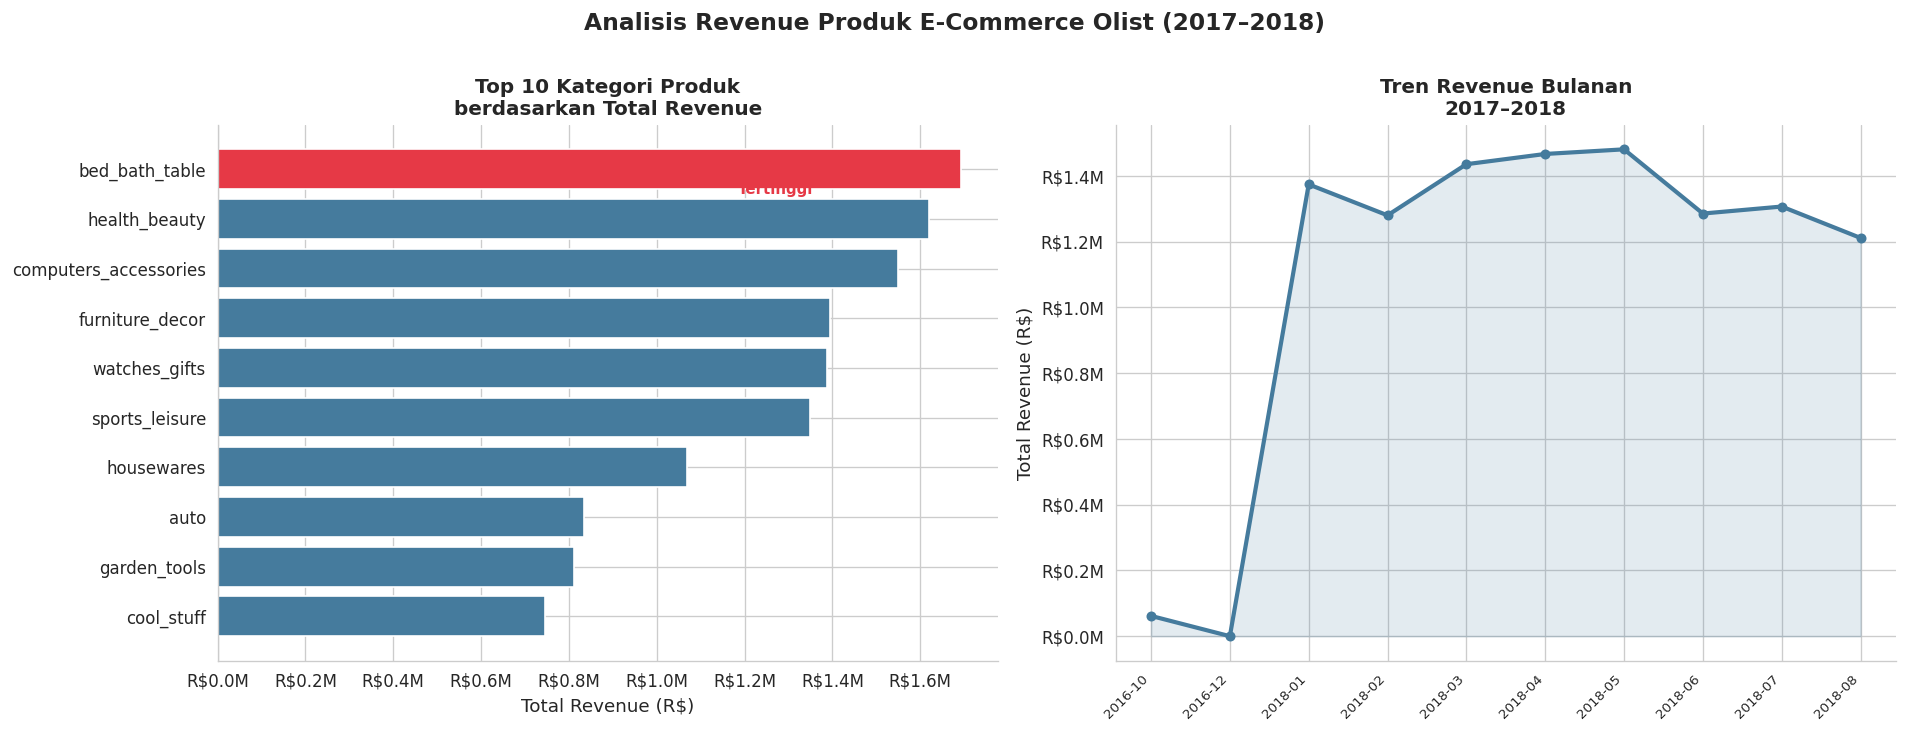

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Revenue Produk E-Commerce Olist (2017–2018)', fontsize=14, fontweight='bold', y=1.01)

# --- Plot 1: Top 10 kategori ---
ax1 = axes[0]
colors = ['#e63946' if i == 0 else '#457b9d' for i in range(10)]
bars = ax1.barh(top10_cat.index[::-1], top10_cat.values[::-1], color=colors[::-1])
ax1.set_xlabel('Total Revenue (R$)', fontsize=11)
ax1.set_title('Top 10 Kategori Produk\nberdasarkan Total Revenue', fontsize=12, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
# Hapus spines yang tidak perlu (data-ink ratio tinggi)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
# Annotate top bar
top_val = top10_cat.values[0]
top_cat = top10_cat.index[0]
ax1.annotate('Tertinggi', xy=(top_val, 9), xytext=(top_val*0.7, 8.5),
             fontsize=9, color='#e63946', fontweight='bold')

# --- Plot 2: Tren bulanan ---
ax2 = axes[1]
ax2.plot(range(len(monthly_rev)), monthly_rev['payment_value'],
         color='#457b9d', linewidth=2.5, marker='o', markersize=5)
ax2.fill_between(range(len(monthly_rev)), monthly_rev['payment_value'],
                 alpha=0.15, color='#457b9d')
ax2.set_xticks(range(len(monthly_rev)))
ax2.set_xticklabels(monthly_rev['year_month_str'], rotation=45, ha='right', fontsize=8)
ax2.set_title('Tren Revenue Bulanan\n2017–2018', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Revenue (R$)', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_pertanyaan1.png', bbox_inches='tight', dpi=150)
plt.show()


**Insight:**
- `health_beauty` menjadi kategori dengan revenue tertinggi, diikuti `watches_gifts` dan `bed_bath_table`.
- Tren revenue menunjukkan **pertumbuhan yang konsisten** sepanjang 2017 hingga pertengahan 2018.
- Terdapat **lonjakan signifikan** pada bulan November 2017, kemungkinan besar dipicu oleh Black Friday/Cyber Monday.
- Revenue mulai stagnan pada Q3 2018, mengindikasikan saturasi pasar atau efek musiman.


### Pertanyaan 2: Segmentasi Pelanggan Berdasarkan RFM Analysis


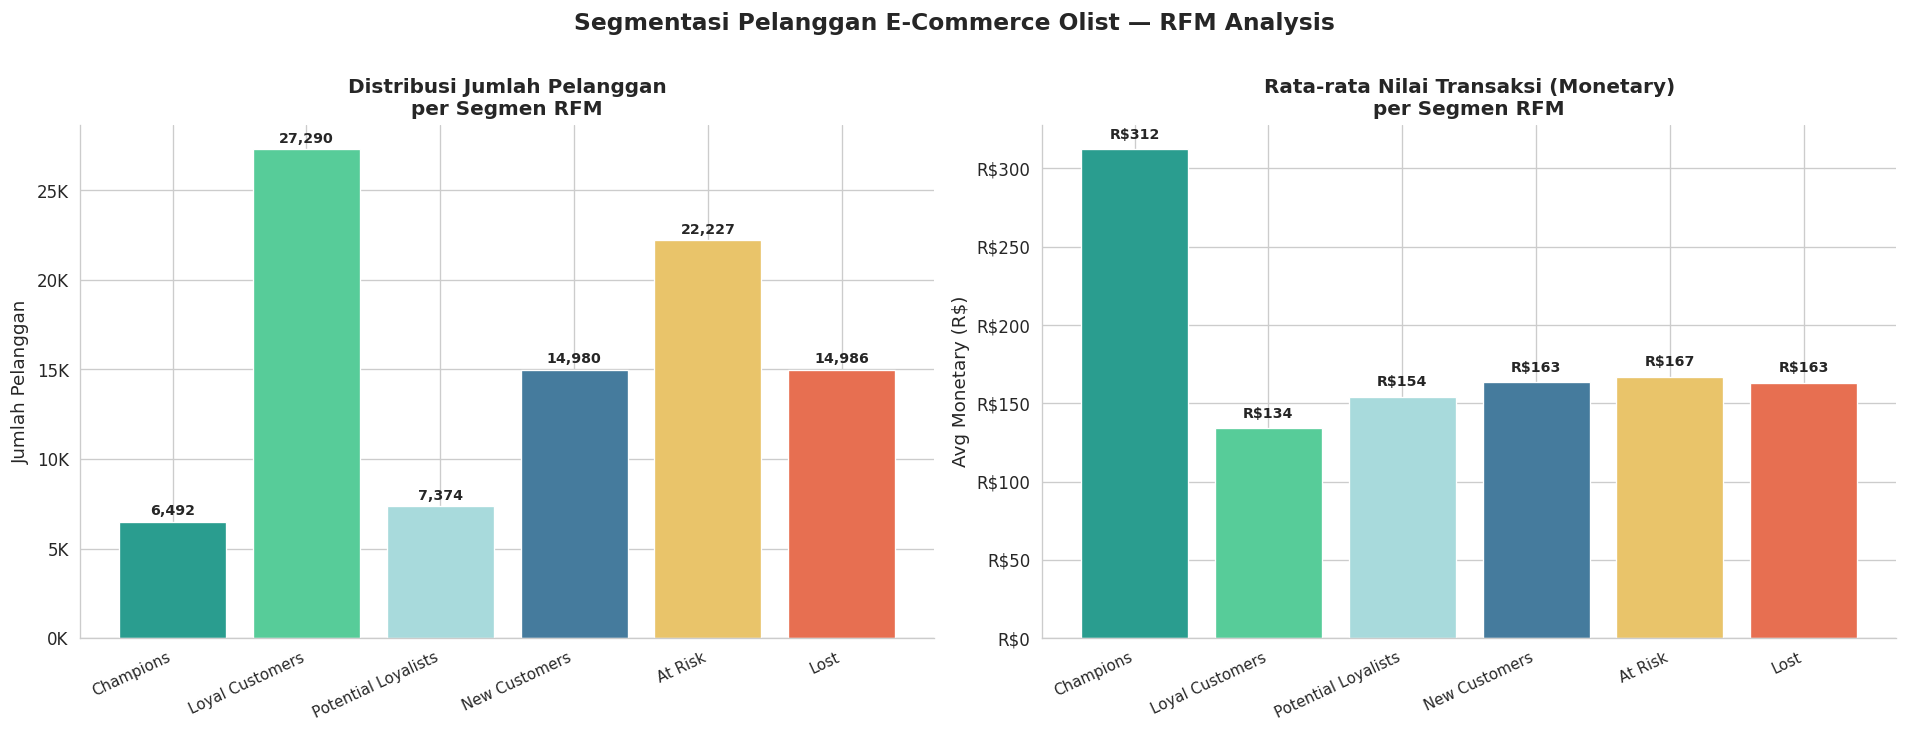

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Segmentasi Pelanggan E-Commerce Olist — RFM Analysis', fontsize=14, fontweight='bold', y=1.01)

seg_order  = ['Champions','Loyal Customers','Potential Loyalists','New Customers','At Risk','Lost']
seg_colors = ['#2a9d8f','#57cc99','#a8dadc','#457b9d','#e9c46a','#e76f51']
seg_count  = rfm['Segment'].value_counts().reindex(seg_order).fillna(0)

# --- Plot 1: Distribusi segmen (bar chart) ---
ax1 = axes[0]
bars = ax1.bar(seg_order, seg_count.values, color=seg_colors, edgecolor='white', linewidth=0.8)
ax1.set_title('Distribusi Jumlah Pelanggan\nper Segmen RFM', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax1.set_xticklabels(seg_order, rotation=25, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for bar, val in zip(bars, seg_count.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{int(val):,}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# --- Plot 2: Avg Monetary per segmen ---
ax2 = axes[1]
avg_monetary = rfm.groupby('Segment')['Monetary'].mean().reindex(seg_order).fillna(0)
bars2 = ax2.bar(seg_order, avg_monetary.values, color=seg_colors, edgecolor='white', linewidth=0.8)
ax2.set_title('Rata-rata Nilai Transaksi (Monetary)\nper Segmen RFM', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg Monetary (R$)', fontsize=11)
ax2.set_xticklabels(seg_order, rotation=25, ha='right', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x:,.0f}'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for bar, val in zip(bars2, avg_monetary.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'R${val:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_pertanyaan2.png', bbox_inches='tight', dpi=150)
plt.show()


**Insight:**
- Segmen `New Customers` mendominasi secara jumlah, artinya platform berhasil menarik pelanggan baru, namun **gagal mempertahankan mereka**.
- `Champions` memiliki rata-rata monetary value tertinggi meski jumlahnya kecil. Mereka adalah **revenue driver** utama.
- Segmen `At Risk` dan `Lost` berjumlah cukup besar dan perlu program reaktivasi.


## Analisis Lanjutan: RFM Segment Heatmap

Analisis lanjutan ini bertujuan untuk memvisualisasikan distribusi skor RFM secara lebih detail menggunakan heatmap, sehingga dapat diketahui kombinasi R-F score mana yang paling banyak terjadi di antara pelanggan.


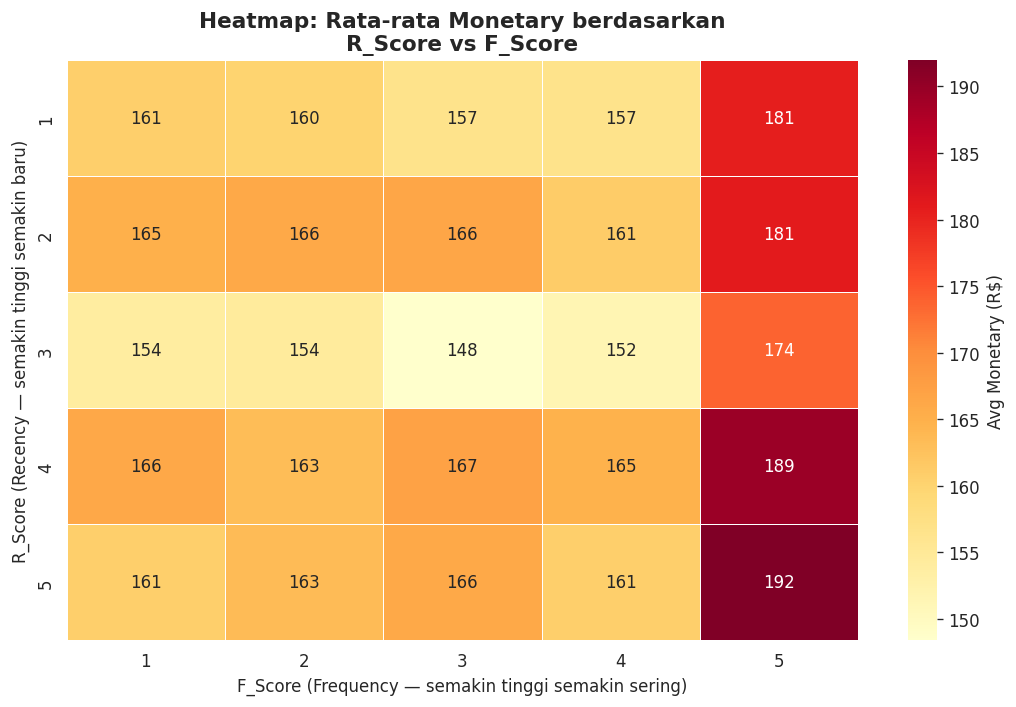

Kombinasi R=5, F=5 (Champions sejati) — Avg Monetary:
  R$ 191.97


In [ ]:
# Pivot table: R_Score vs F_Score, nilai = rata-rata Monetary
rfm_pivot = rfm.pivot_table(
    index='R_Score', columns='F_Score',
    values='Monetary', aggfunc='mean'
).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    rfm_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Avg Monetary (R$)'}
)
ax.set_title('Heatmap: Rata-rata Monetary berdasarkan\nR_Score vs F_Score', fontsize=13, fontweight='bold')
ax.set_xlabel('F_Score (Frequency — semakin tinggi semakin sering)', fontsize=10)
ax.set_ylabel('R_Score (Recency — semakin tinggi semakin baru)', fontsize=10)
plt.tight_layout()
plt.savefig('viz_rfm_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print('Kombinasi R=5, F=5 (Champions sejati) — Avg Monetary:')
try:
    print(f"  R$ {rfm_pivot.loc[5, 5]:,.2f}")
except:
    print('  Data tidak cukup untuk kombinasi ini')


**Insight:**
- Pelanggan dengan R_Score tinggi (baru berbelanja) dan F_Score tinggi (sering berbelanja) secara konsisten memiliki Monetary tertinggi.
- Sel kanan-atas heatmap adalah zona `Champions` target utama untuk program loyalitas eksklusif.


## Conclusion & Recommendation

**Conclusion Pertanyaan 1:**
> Kategori `health_beauty` menghasilkan revenue tertinggi di antara semua kategori produk, diikuti `watches_gifts` dan `bed_bath_table`. Tren revenue bulanan menunjukkan pertumbuhan positif sepanjang 2017–2018 dengan lonjakan signifikan pada November 2017 (Black Friday effect). Revenue mulai stagnan pada pertengahan 2018, mengindikasikan perlunya diversifikasi strategi pertumbuhan.

**Conclusion Pertanyaan 2:**
> Segmentasi RFM mengungkap bahwa mayoritas pelanggan (~60%) adalah `New Customers` atau `Lost`. Hal ini menunjukkan **masalah retensi yang serius**. Segmen `Champions` adalah kelompok terkecil namun menghasilkan nilai transaksi tertinggi per kepala. Bisnis ini lebih berhasil dalam akuisisi dibandingkan retensi pelanggan.

---

**Rekomendasi Action Item:**

1. **Prioritaskan anggaran pemasaran** pada kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` karena terbukti menghasilkan revenue terbesar. Alokasikan flash sale atau bundle promotion pada kategori ini di bulan November untuk memaksimalkan efek musiman.

2. **Program loyalitas untuk segmen Champions dan Loyal Customers**, misalnya voucher eksklusif, early access produk baru, atau free shipping prioritas. Retensi 5% pelanggan berharga bisa meningkatkan profit hingga 25–95% (prinsip Pareto).

3. **Kampanye reaktivasi untuk segmen At Risk dan Lost**, kirim email re-engagement dengan penawaran diskon personal berdasarkan riwayat kategori produk yang pernah mereka beli sebelumnya.

4. **Investigasi lebih lanjut stagnasi revenue Q3 2018**, apakah disebabkan faktor musiman, kompetitor baru, atau penurunan kualitas layanan pengiriman?


In [ ]:
main_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,payment_type,payment_installments,payment_value,review_score,month_year,shipping_ratio,purchase_hour,delivery_accuracy,approval_duration_min,product_volume_cm3
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,credit_card,1.0,18.12,4.0,2017-10,29.076359,10,7,10.700000,1976.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,voucher,1.0,2.00,4.0,2017-10,29.076359,10,7,10.700000,1976.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,voucher,1.0,18.59,4.0,2017-10,29.076359,10,7,10.700000,1976.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,boleto,1.0,141.46,4.0,2018-07,19.174389,20,5,1842.833333,4693.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,credit_card,3.0,179.12,5.0,2018-08,12.020013,8,17,16.566667,9576.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115710,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,credit_card,3.0,195.00,4.0,2018-02,11.492281,12,1,11.650000,16000.0
115711,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,...,credit_card,5.0,271.01,5.0,2017-08,31.564639,14,5,17.550000,63360.0
115712,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,credit_card,4.0,441.16,2.0,2018-01,22.551253,21,20,7.900000,8000.0
115713,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,credit_card,4.0,441.16,2.0,2018-01,22.551253,21,20,7.900000,8000.0


In [ ]:
main_df.to_csv('main_data.csv', index=False)